<a href="https://colab.research.google.com/github/ClaudiaTurner/GEOG5990M/blob/main/Final_Project_Python_GEOG5990M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEOG5990M Final Assignment (Template)

Student ID number: 201893759

In [ ]:
# read in required packages

This is an example block of mardown text I want to reference <a href="#ref1">[1]</a>. I might need to add some more citations <a href="#ref2">[2]</a><a href="#ref2">[3]</a>



Data Visualisation
- Don't forget to present your final two data visualisation (one spatial and one non-spatial) and the justifications about the decisions you made whilst preparing and visualising the data.

**PACKAGE IMPORTS & DATA LOADING**

In [1]:
# To begin, I will import the packages I will use in block 1


import pandas as pd  # Used for uploading and handling data (e.g., upload CSV) (Nelli, 2023).

import matplotlib.pyplot as plt  # Used for creating visualisations (e.g., line chart) (Walker, 2020).

import numpy as np  # Used for numerical operations (e.g., create a range of years) (Walker, 2020).

import seaborn as sns  # Makes it easier to create attractive and informative statistical graphics (e.g., barplot) (Rajagopalan,2021)


###### These are counts of how many properties were sold each year, not the value (£) they were sold for.

In [2]:
# LOAD DATA
#The DataFrame contains information on count of house sales from 1996 to 2023, across all districts in England. Our analysis will cover 2000 to 2023.
# To upload the data (CSV), I’ll paste the GitHub file path below:

Sales_England=pd.read_csv('https://github.com/ClaudiaTurner/GEOG5990M/raw/main/DATA/Eng_sales_1996_2023_.csv')


# To understand the data better, I'll take a quick look at the first six rows

display(Sales_England.head(6))

# I added row and column info below the table, with a title and a line break for clarity.
print('\nNumber of rows and columns:')
print(Sales_England.shape)


,Residential property sales,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30
0,ONS Crown Copyright Reserved [from Nomis on 9 ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Count of sales:,Sales,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Area,mnemonic,row,Sep-96,Sep-97,Sep-98,Sep-99,Sep-00,Sep-01,Sep-02,...,Sep-14,Sep-15,Sep-16,Sep-17,Sep-18,Sep-19,Sep-20,Sep-21,Sep-22,Sep-23
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,country:England,E92000001,1,850013,1047268,1016037,1084672,1130983,1133620,1271168,...,877425,854379,903005,852771,829715,803012,669410,1081660,787290,573646



Number of rows and columns:
(324, 31)


**DATA CLEANING**

In [4]:
# The original CSV had extra information in rows 1, 2, 3, and 4, making the data messy.
# For example, 'Unnamed: 1' was just a blank row in the original file.
# The column titles should be in the fifth row — years like 'Sep-96', 'Area', etc.
## To clean the data, I will start by removing the first four rows using the 'skiprows' function (Walker, 2020).
## This will eliminate everything above the actual headers.

Sales_England = pd.read_csv('https://github.com/ClaudiaTurner/GEOG5990M/raw/main/Sales_1995_2023_England_Districts_exp.csv', skiprows=4)

# Confirm the changes
Sales_England.head()


,row,Sep-96,Sep-97,Sep-98,Sep-99,Sep-00,Sep-01,Sep-02,Sep-03,Sep-04,...,Sep-16,Sep-17,Sep-18,Sep-19,Sep-20,Sep-21,Sep-22,Sep-23,Area,mnemonic
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,850013.0,1047268.0,1016037.0,1084672.0,1130983.0,1133620.0,1271168.0,1153345.0,1264229.0,...,903005.0,852771.0,829715.0,803012.0,669410.0,1081660.0,787290.0,573646.0,country:England,E92000001
2,2.0,1159.0,1390.0,1405.0,1440.0,1726.0,2140.0,2359.0,2488.0,2979.0,...,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,1103.0,ladu2023:Hartlepool,E06000001
3,3.0,1776.0,1934.0,1948.0,2055.0,2280.0,2462.0,2826.0,3016.0,3339.0,...,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,1298.0,ladu2023:Middlesbrough,E06000002
4,4.0,1879.0,2000.0,1957.0,1986.0,2266.0,2582.0,3497.0,3390.0,3138.0,...,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0,1667.0,ladu2023:Redcar and Cleveland,E06000003


In [5]:
# Our analysis should include years (2000 - 2023), hence we can eliminate the rest of the years
# Additionally, we also eliminate 'row' because we already have the table's row enumeration
Sales_England = Sales_England.drop(columns=[
    'row', 'Sep-96', 'Sep-97', 'Sep-98', 'Sep-99',])

# After eliminating many columns, ill check if the columns were successfully eliminated
Sales_England.columns.tolist()   # .tolist() converts the column index into a regular Python list

['Sep-00',
 'Sep-01',
 'Sep-02',
 'Sep-03',
 'Sep-04',
 'Sep-05',
 'Sep-06',
 'Sep-07',
 'Sep-08',
 'Sep-09',
 'Sep-10',
 'Sep-11',
 'Sep-12',
 'Sep-13',
 'Sep-14',
 'Sep-15',
 'Sep-16',
 'Sep-17',
 'Sep-18',
 'Sep-19',
 'Sep-20',
 'Sep-21',
 'Sep-22',
 'Sep-23',
 'Area',
 'mnemonic']

In [6]:
# RENAME COLUMNS

#To further clean and enhance the data, I'll rename and reorder the columns.
# I'll also change the date format from 'Sep-13' to '2013' for all years to improve readability. # To update the file, I can use either 'Sales_England =' or set 'inplace=True'.

Sales_England = Sales_England.rename(columns={
  'Sep-00':'2000','Sep-01':'2001', 'Sep-02':'2002', 'Sep-03':'2003', 'Sep-04':'2004',
    'Sep-05':'2005', 'Sep-06':'2006', 'Sep-07':'2007', 'Sep-08':'2008', 'Sep-09':'2009',
    'Sep-10':'2010', 'Sep-11':'2011', 'Sep-12':'2012','Sep-13': '2013', 'Sep-14': '2014', 'Sep-15': '2015', 'Sep-16': '2016', 'Sep-17': '2017',
    'Sep-18': '2018','Sep-19': '2019','Sep-20': '2020','Sep-21': '2021','Sep-22': '2022','Sep-23': '2023','Area': 'DISTRICT','mnemonic': 'CODE_LAD'})

#REORDER COLUMNS

# 2. Reorder the columns so that the district name and code appear before the years.
# After runing this code: 'Sales_England = Sales_England[['DISTRICT', 'CODE_LAD'] + [str(y) for y in range(2000, 2023)]]', year 2023 disappeared
## Thus I asked Copilot (ADD VERSION): 'After introducing the code, year 2023 is not visible, why?'
## Copilot:  in Python, range(...) excludes the end value, so 2023 is not included.

Sales_England = Sales_England[['DISTRICT', 'CODE_LAD'] + [str(y) for y in range(2000, 2024)]]


# Check the last 5 rows to confirm changes.
Sales_England.tail()


,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
315,ladu2023:Torfaen,W06000020,1461.0,1438.0,1612.0,1511.0,1482.0,1079.0,1488.0,1695.0,...,1091.0,985.0,1103.0,1324.0,1438.0,1464.0,1060.0,1520.0,1392.0,928.0
316,ladu2023:Monmouthshire,W06000021,2038.0,1867.0,2038.0,1696.0,2082.0,1433.0,1543.0,1739.0,...,1413.0,1399.0,1584.0,1557.0,1482.0,1307.0,1054.0,1936.0,1556.0,1030.0
317,ladu2023:Newport,W06000022,2856.0,2935.0,3464.0,3003.0,3101.0,2396.0,2938.0,2757.0,...,2016.0,2178.0,2761.0,3021.0,2869.0,2503.0,1798.0,2634.0,2440.0,1763.0
318,ladu2023:Powys,W06000023,2048.0,2094.0,2101.0,2179.0,2341.0,1734.0,2066.0,2279.0,...,1650.0,1635.0,1743.0,1827.0,1880.0,1802.0,1383.0,2394.0,1831.0,1284.0
319,ladu2023:Merthyr Tydfil,W06000024,762.0,779.0,1000.0,1016.0,1061.0,840.0,977.0,1006.0,...,683.0,706.0,786.0,745.0,682.0,725.0,577.0,818.0,781.0,527.0


In [ ]:
#Sales_England.dtypes

In [6]:
# NULL VALUES

#Search for null values
# Explain why we have null values
Sales_England.isnull().sum()

,0
DISTRICT,1
CODE_LAD,1
2000,1
2001,1
2002,1
2003,1
2004,1
2005,1
2006,1
2007,1


In [7]:
# Eliminate null values
Sales_England = Sales_England.dropna()

# .info() shows column names, data types, non-null counts, and memory usage (Walker, 2020.
Sales_England.head(3)

,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
1,country:England,E92000001,1130983.0,1133620.0,1271168.0,1153345.0,1264229.0,976245.0,1203858.0,1279204.0,...,877425.0,854379.0,903005.0,852771.0,829715.0,803012.0,669410.0,1081660.0,787290.0,573646.0
2,ladu2023:Hartlepool,E06000001,1726.0,2140.0,2359.0,2488.0,2979.0,2123.0,2285.0,2290.0,...,1113.0,1205.0,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,1103.0
3,ladu2023:Middlesbrough,E06000002,2280.0,2462.0,2826.0,3016.0,3339.0,2817.0,3139.0,3514.0,...,1556.0,1748.0,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,1298.0


In [8]:
# ELIMINATE ROW

#Drop the first row (Country: England) by specifying its index.
# We're removing it because the data is unclear and not useful.
# Later on, we'll create a new row to calculate the total amount per year. index[0] selects the first row in the table.

Sales_England = Sales_England.drop(Sales_England.index[0]).reset_index(drop=True) # .reset_index(drop=True) resets row numbering to start at 0
                                                                                  # e.g., instead of index 1, 2, 3... → becomes 0, 1, 2...

# The first row has now been removed. Check the first 3 rows to confirm.
Sales_England.head(3)


,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,ladu2023:Hartlepool,E06000001,1726.0,2140.0,2359.0,2488.0,2979.0,2123.0,2285.0,2290.0,...,1113.0,1205.0,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,1103.0
1,ladu2023:Middlesbrough,E06000002,2280.0,2462.0,2826.0,3016.0,3339.0,2817.0,3139.0,3514.0,...,1556.0,1748.0,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,1298.0
2,ladu2023:Redcar and Cleveland,E06000003,2266.0,2582.0,3497.0,3390.0,3138.0,2406.0,2945.0,3376.0,...,1918.0,1773.0,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0,1667.0


In [9]:
# MODIFY ROWS

# Aditionally, I'll remove the 'ladu2023:' prefix from all values in the 'DISTRICT' column to clean up the district names.

Sales_England['DISTRICT'] = Sales_England['DISTRICT'].str.replace('ladu2023:', '')

# The prefix in the district names is no longer visible. Briefly check the first 5 rowa
Sales_England.head()

,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Hartlepool,E06000001,1726.0,2140.0,2359.0,2488.0,2979.0,2123.0,2285.0,2290.0,...,1113.0,1205.0,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,1103.0
1,Middlesbrough,E06000002,2280.0,2462.0,2826.0,3016.0,3339.0,2817.0,3139.0,3514.0,...,1556.0,1748.0,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,1298.0
2,Redcar and Cleveland,E06000003,2266.0,2582.0,3497.0,3390.0,3138.0,2406.0,2945.0,3376.0,...,1918.0,1773.0,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0,1667.0
3,Stockton-on-Tees,E06000004,3978.0,4168.0,5320.0,4610.0,4471.0,3293.0,4341.0,4901.0,...,2724.0,2685.0,2922.0,2959.0,3090.0,3066.0,2523.0,3826.0,3063.0,2186.0
4,Darlington,E06000005,2538.0,2770.0,3033.0,2926.0,3288.0,2287.0,2771.0,3033.0,...,1589.0,1705.0,1679.0,1642.0,1602.0,1616.0,1501.0,2435.0,1885.0,1339.0


In [10]:
# CALCULATE TOTAL AMOUNT OF SALES PER DISTRICT (2000 - 2023)

# 1. Identify year columns by selecting only numerical columns (type float64),
# which correspond to annual sales data. This excludes non-numerical metadata columns
# like 'DISTRICT' and 'CODE_LAD' automatically.

year_columns = Sales_England.select_dtypes(include='number').columns

# 2. Sum across the selected year columns (per row) to calculate the total number of sales
# for each district (LAD) across all years.
# axis=1 means the operation is performed **horizontally across columns** (i.e., across years for each row).

Sales_England['TOTAL_SALES_LAD'] = Sales_England[year_columns].sum(axis=1)
Sales_England.head(4)

,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,TOTAL_SALES_LAD
0,Hartlepool,E06000001,1726.0,2140.0,2359.0,2488.0,2979.0,2123.0,2285.0,2290.0,...,1205.0,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,1103.0,36918.0
1,Middlesbrough,E06000002,2280.0,2462.0,2826.0,3016.0,3339.0,2817.0,3139.0,3514.0,...,1748.0,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,1298.0,49516.0
2,Redcar and Cleveland,E06000003,2266.0,2582.0,3497.0,3390.0,3138.0,2406.0,2945.0,3376.0,...,1773.0,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0,1667.0,51496.0
3,Stockton-on-Tees,E06000004,3978.0,4168.0,5320.0,4610.0,4471.0,3293.0,4341.0,4901.0,...,2685.0,2922.0,2959.0,3090.0,3066.0,2523.0,3826.0,3063.0,2186.0,78308.0


In [11]:
# CALCULATE AVERAGE SALES FOR ALL DISTRICTS

# 1. Dynamically find all year columns between 2000 and 2023.
# This avoids hardcoding and ensures the list only includes numeric year labels.
year_cols = [col for col in Sales_England.columns if col.isdigit() and 2000 <= int(col) <= 2023]

# 2. Calculate the row-wise average across those year columns (i.e., for each district)
# axis=1 means we're averaging values horizontally, across the years for each district.
Sales_England['AVERAGE'] = Sales_England[year_cols].mean(axis=1)

# 3. Round the average to 1 decimal place for easier readability
Sales_England['AVERAGE'] = Sales_England['AVERAGE'].round(0)

# 4. Preview the result
Sales_England.head(4)

,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2016,2017,2018,2019,2020,2021,2022,2023,TOTAL_SALES_LAD,AVERAGE
0,Hartlepool,E06000001,1726.0,2140.0,2359.0,2488.0,2979.0,2123.0,2285.0,2290.0,...,1273.0,1209.0,1304.0,1235.0,1050.0,1729.0,1490.0,1103.0,36918.0,1538.0
1,Middlesbrough,E06000002,2280.0,2462.0,2826.0,3016.0,3339.0,2817.0,3139.0,3514.0,...,1822.0,1749.0,1819.0,1828.0,1528.0,2316.0,2035.0,1298.0,49516.0,2063.0
2,Redcar and Cleveland,E06000003,2266.0,2582.0,3497.0,3390.0,3138.0,2406.0,2945.0,3376.0,...,1824.0,1947.0,2007.0,1967.0,1636.0,2539.0,2081.0,1667.0,51496.0,2146.0
3,Stockton-on-Tees,E06000004,3978.0,4168.0,5320.0,4610.0,4471.0,3293.0,4341.0,4901.0,...,2922.0,2959.0,3090.0,3066.0,2523.0,3826.0,3063.0,2186.0,78308.0,3263.0


In [ ]:
# maybe here add total amount of england per year, also adding the average summ that should match the total...

In [12]:
# NEW ROW: TOTAL SALES AMOUNT PER YEAR IN ENGLAND

# This section adds a new row that sums the total property sales across all districts,
# for each year and for the entire dataset. The row will help visualize or compare
# national-level trends vs. individual districts.

# 1. Identify which columns are numeric (i.e., actual sales figures for each year),
# and which are non-numeric (e.g., 'DISTRICT', 'CODE_LAD', etc.)
numeric_cols = Sales_England.select_dtypes(include='number').columns
non_numeric_cols = [col for col in Sales_England.columns if col not in numeric_cols]

# 2. Sum all sales data across numeric columns (i.e., total number of properties sold per year)
england_totals = Sales_England[numeric_cols].sum()

# 3. For the non-numeric fields like 'DISTRICT' or 'CODE_LAD',
# insert a clear label so we can identify this row as a total (not a real district)
for col in non_numeric_cols:
    england_totals[col] = 'ENGLAND_TOTAL_SALES'

# 4. Reorder the new row to match the same column order as the original DataFrame
england_totals = england_totals[Sales_England.columns]

# 5. Append this total row to the original DataFrame
Sales_England = pd.concat([Sales_England, pd.DataFrame([england_totals])], ignore_index=True)

# 6. Optional: display last few rows to verify that the new row has been added
Sales_England.tail()


,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2016,2017,2018,2019,2020,2021,2022,2023,TOTAL_SALES_LAD,AVERAGE
314,Monmouthshire,W06000021,2038.0,1867.0,2038.0,1696.0,2082.0,1433.0,1543.0,1739.0,...,1584.0,1557.0,1482.0,1307.0,1054.0,1936.0,1556.0,1030.0,35065.0,1461.0
315,Newport,W06000022,2856.0,2935.0,3464.0,3003.0,3101.0,2396.0,2938.0,2757.0,...,2761.0,3021.0,2869.0,2503.0,1798.0,2634.0,2440.0,1763.0,55795.0,2325.0
316,Powys,W06000023,2048.0,2094.0,2101.0,2179.0,2341.0,1734.0,2066.0,2279.0,...,1743.0,1827.0,1880.0,1802.0,1383.0,2394.0,1831.0,1284.0,41923.0,1747.0
317,Merthyr Tydfil,W06000024,762.0,779.0,1000.0,1016.0,1061.0,840.0,977.0,1006.0,...,786.0,745.0,682.0,725.0,577.0,818.0,781.0,527.0,17607.0,734.0
318,ENGLAND_TOTAL_SALES,ENGLAND_TOTAL_SALES,1185922.0,1190392.0,1338117.0,1216187.0,1328075.0,1022613.0,1260377.0,1340853.0,...,948962.0,899937.0,877152.0,849682.0,704696.0,1135971.0,833859.0,606637.0,22666876.0,944453.0


In [19]:
Sales_England.loc[Sales_England['DISTRICT'] == 'City of London']

,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2017,2018,2019,2020,2021,2022,2023,TOTAL_SALES,AVERAGE,TOTAL_SALES_LAD
172,City of London,E09000001,525.0,387.0,360.0,456.0,437.0,283.0,295.0,295.0,...,202.0,338.0,186.0,136.0,242.0,188.0,136.0,6635.0,276.458333,13546.458333


In [20]:
Sales_England.nlargest(6, 'AVERAGE')[['DISTRICT', 'AVERAGE']]

,DISTRICT,AVERAGE
319,ENGLAND_TOTAL_SALES,1.888906e+06
318,ENGLAND_TOTAL_SALES,9.444532e+05
120,Birmingham,1.375162e+04
60,Leeds,1.262821e+04
52,North Yorkshire,1.114258e+04
276,Cornwall,1.030992e+04


<ipython-input-20-f731504b923b>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=year_data.index, y=year_data.values, palette='colorblind')


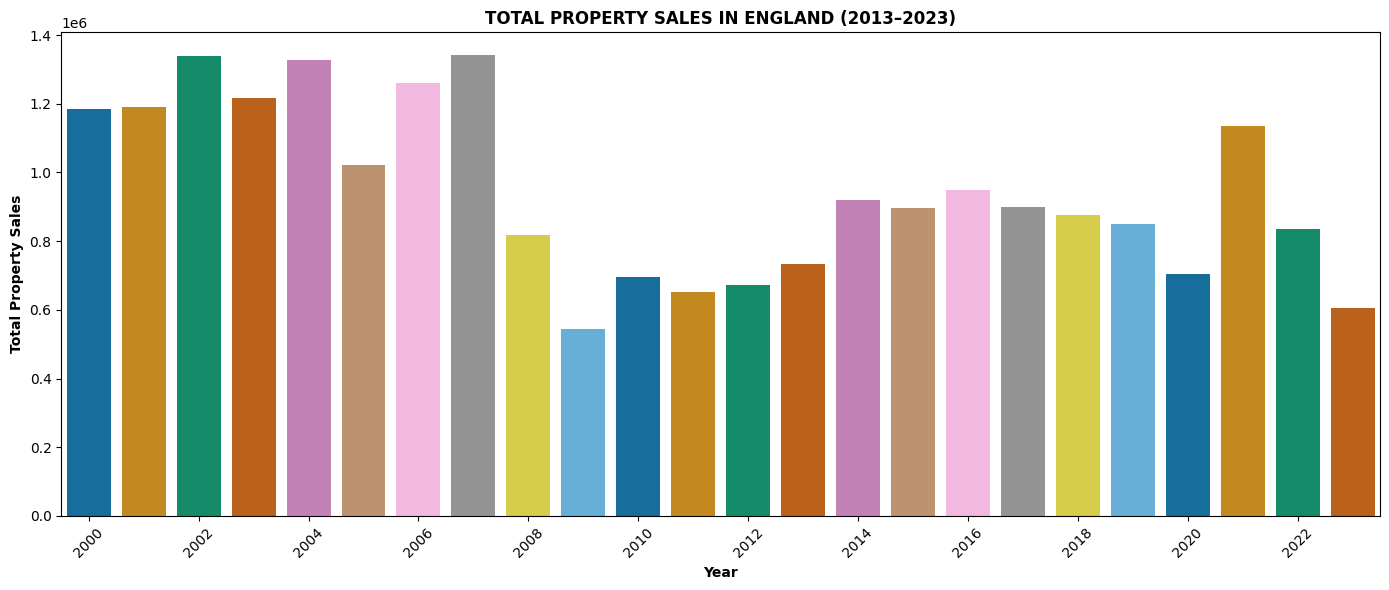

In [20]:
# COLOR BLIND

# CHANGE Y TO REAL VALUES

# 1. Extract the summary row labeled 'ENGLAND_TOTAL_YEAR' from the DISTRICT column
# This row represents total annual property sales across all districts
sum_row = Sales_England[Sales_England['DISTRICT'] == 'ENGLAND_TOTAL_SALES']

# 2. Dynamically select only the columns that represent years (e.g., 2013 to 2023)
year_columns = [col for col in sum_row.columns if col.isnumeric()]

# 3. Extract the yearly sales data and flatten it into a 1D array for plotting
year_data = sum_row[year_columns].squeeze()

# 4. Create the bar chart
plt.figure(figsize=(14, 6))  # Set plot dimensions (width x height)

# Use a color-blind-friendly palette ('colorblind') to improve accessibility
sns.barplot(x=year_data.index, y=year_data.values, palette='colorblind')

# 5. Customize the X-axis to show every 2 years
plt.xticks(ticks=np.arange(0, len(year_data), 2),
           labels=year_data.index[::2], rotation=45)

# 6. Add axis labels and a bold title
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Total Property Sales", fontweight='bold')
plt.title("TOTAL PROPERTY SALES IN ENGLAND (2013–2023)", fontweight='bold')

# 7. Clean and render the plot
plt.tight_layout()  # Adjust spacing to prevent overlap
plt.show()

In [ ]:
Sales_England['MOST_COMMON_YEARS']=Sales_England[['2000','2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011','2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']].idxmax(axis=1)

Sales_England.head(10)





In [ ]:

Sales_England['MOST_COMMON_YEARS'].value_counts()

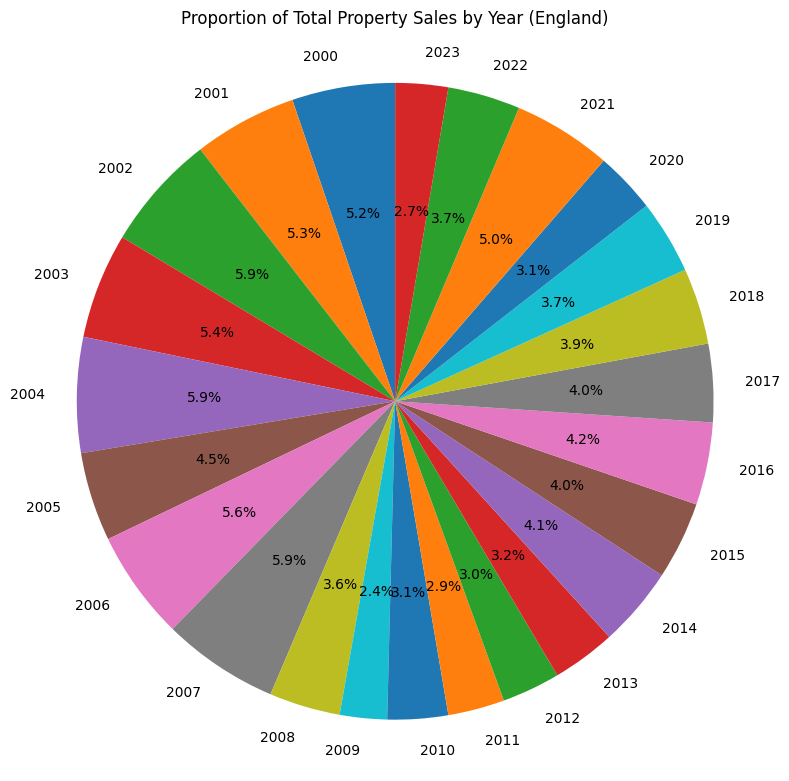

In [14]:

# 1. Extract the England sum row
sum_row = Sales_England[Sales_England['DISTRICT'] == 'ENGLAND_TOTAL_YEAR']

# 2. Select only the year columns (numeric string names like '1996', '1997', ...)
year_columns = [col for col in sum_row.columns if col.isnumeric()]
year_data = sum_row[year_columns].squeeze()

# 3. Create pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    year_data.values,
    labels=year_data.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Proportion of Total Property Sales by Year (England)')
plt.axis('equal')  # Keeps the pie circular
plt.tight_layout()
plt.show()

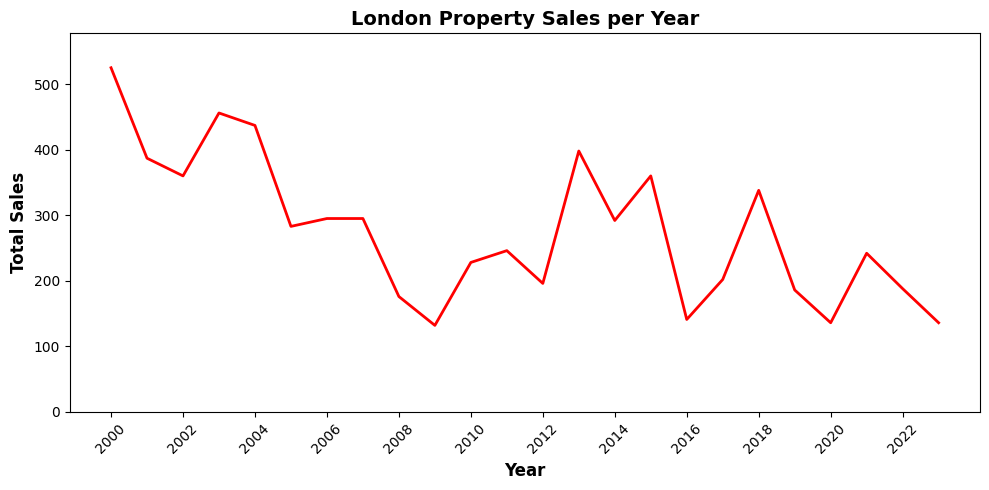

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter only London districts (case-insensitive)
london_df = Sales_England[Sales_England['DISTRICT'].str.contains('london', case=False)]

# 2. Get year columns (e.g., '1996' to '2023')
year_columns = [col for col in london_df.columns if col.isnumeric()]

# 3. Sum sales across all London districts for each year
london_yearly_sales = london_df[year_columns].sum()

# 4. Convert year labels to integers for proper numeric plotting
x_years = london_yearly_sales.index.astype(int)
y_sales = london_yearly_sales.values

# 5. Create the figure with a clean white background
plt.figure(figsize=(10, 5), facecolor='white')

# 6. Plot the red sales trend line
plt.plot(x_years, y_sales, color='red', linewidth=2)

# 7. Add formal title and axis labels
plt.title("London Property Sales per Year", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12, fontweight='bold')
plt.ylabel("Total Sales", fontsize=12, fontweight='bold')

# 8. X-axis: show every 2 years, with rotated labels
tick_years = np.arange(x_years.min(), x_years.max() + 1, 2)
plt.xticks(ticks=tick_years, rotation=45, fontsize=10)

# 9. Y-axis: proportional scaling with slight padding
plt.ylim(0, y_sales.max() * 1.1)
plt.yticks(fontsize=10)

# 10. Clean visual: no gridlines
plt.grid(False)

# 11. Tight layout and high-resolution export
plt.tight_layout()
plt.savefig("london_property_sales_trend_clean.png", dpi=300, bbox_inches='tight')

# 12. Display the plot
plt.show()


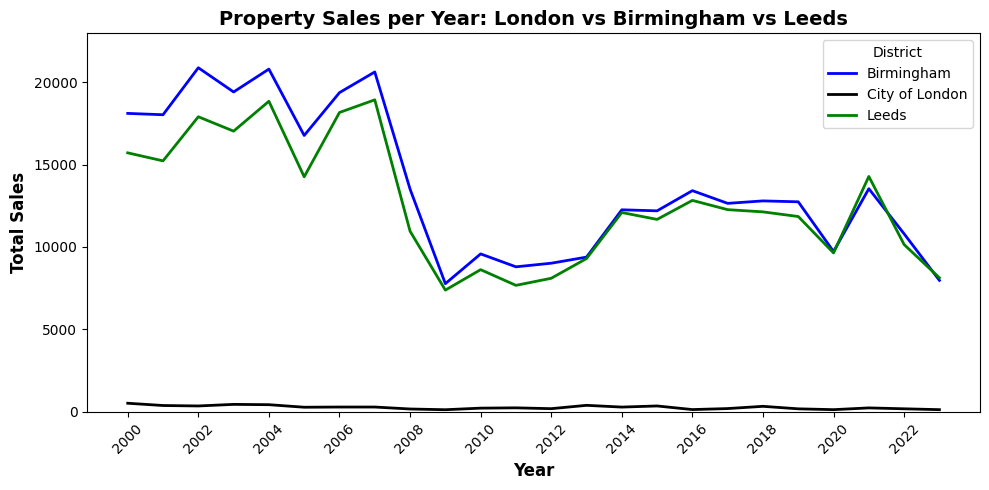

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter the DataFrame for London, Birmingham, and Leeds (case-insensitive)
target_districts = Sales_England[Sales_England['DISTRICT'].str.contains('london|birmingham|leeds', case=False)]

# 2. Get year columns (those that are numeric)
year_columns = [col for col in target_districts.columns if col.isnumeric()]

# 3. Group by district and sum (only needed if multiple rows per district)
district_yearly_sales = target_districts.groupby('DISTRICT')[year_columns].sum()

# 4. Prepare the x-axis (years)
x_years = np.array(year_columns).astype(int)

# 5. Start the plot
plt.figure(figsize=(10, 5), facecolor='white')

# 6. Plot each district separately with distinct color and label
colors = {'London': 'red', 'Birmingham': 'blue', 'Leeds': 'green'}
for district in district_yearly_sales.index:
    plt.plot(
        x_years,
        district_yearly_sales.loc[district].values,
        label=district,
        color=colors.get(district, 'black'),
        linewidth=2
    )

# 7. Add title and axis labels
plt.title("Property Sales per Year: London vs Birmingham vs Leeds", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12, fontweight='bold')
plt.ylabel("Total Sales", fontsize=12, fontweight='bold')

# 8. Format ticks
tick_years = np.arange(x_years.min(), x_years.max() + 1, 2)
plt.xticks(ticks=tick_years, rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# 9. Adjust plot limits
plt.ylim(0, district_yearly_sales.values.max() * 1.1)

# 10. Add legend and clean layout
plt.legend(title="District", fontsize=10)
plt.grid(False)
plt.tight_layout()

# 11. Save and display
plt.savefig("london_birmingham_leeds_sales_trend.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1600x600 with 0 Axes>

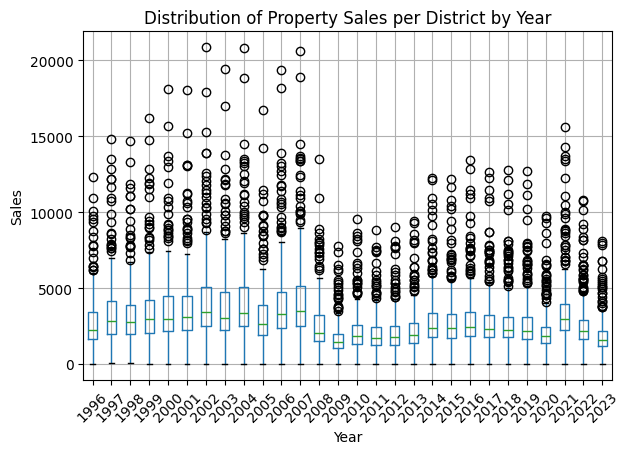

In [ ]:
import matplotlib.pyplot as plt

# Assuming melted is prepared like before (one row per LAD per year)
year_columns = [col for col in Sales_England.columns if col.isnumeric()]
data_clean = Sales_England[~Sales_England['DISTRICT'].str.contains('England_sum', case=False)]
melted = data_clean.melt(id_vars='DISTRICT', value_vars=year_columns, var_name='Year', value_name='Sales')

# Matplotlib boxplot grouped by year
plt.figure(figsize=(16, 6))
melted.boxplot(column='Sales', by='Year')
plt.title("Distribution of Property Sales per District by Year")
plt.suptitle("")  # Remove default matplotlib group title
plt.xticks(rotation=45)
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

<ipython-input-20-e7d5f05fc5c6>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AVERAGE', y='DISTRICT', data=top_avg_districts, palette='coolwarm')


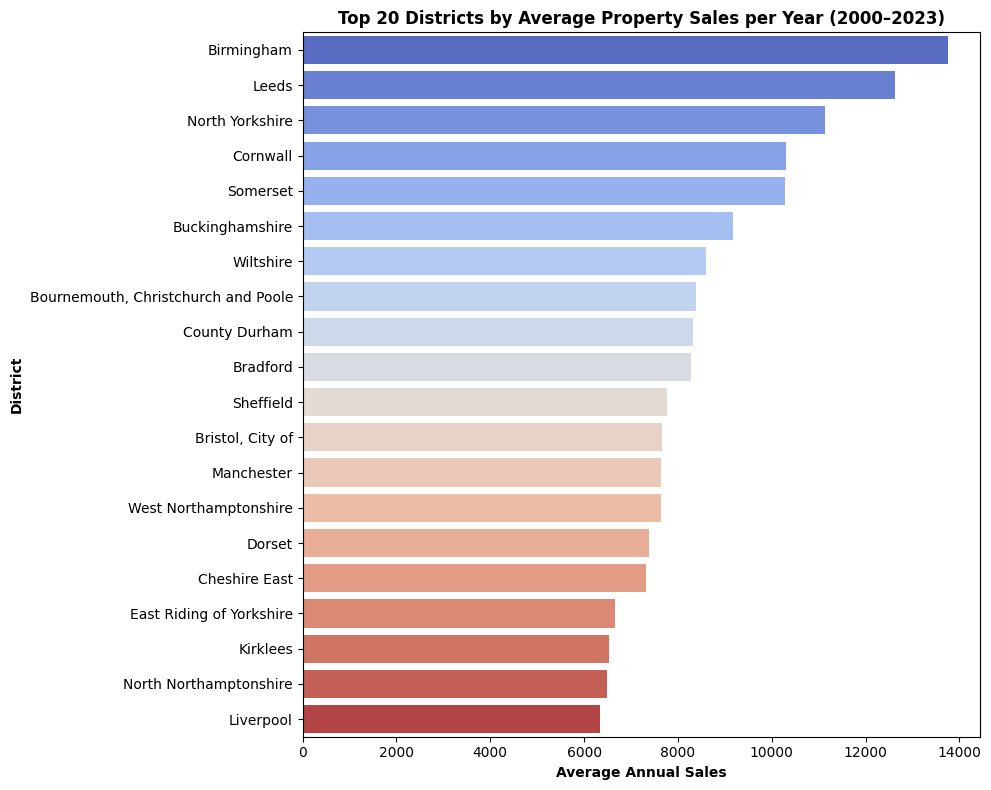

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Remove the summary row
filtered_sales = Sales_England[Sales_England['DISTRICT'] != 'ENGLAND_TOTAL_YEAR']

# 2. Sort by AVERAGE and get the top 20
top_avg_districts = filtered_sales.sort_values('AVERAGE', ascending=False).head(20)

# 3. Create the bar plot
plt.figure(figsize=(10, 8))
sns.barplot(x='AVERAGE', y='DISTRICT', data=top_avg_districts, palette='coolwarm')

# 4. Customize labels and layout
plt.title("Top 20 Districts by Average Property Sales per Year (2000–2023)", fontweight='bold')
plt.xlabel("Average Annual Sales", fontweight='bold')
plt.ylabel("District", fontweight='bold')
plt.tight_layout()

# 5. Show the chart
plt.show()

,DISTRICT,CODE_LAD,2000,2001,2002,2003,2004,2005,2006,2007,...,2018,2019,2020,2021,2022,2023,TOTAL_SALES,AVERAGE,TOTAL_SALES_LAD,MOST_COMMON_YEARS
0,Hartlepool,E06000001,1726.0,2140.0,2359.0,2488.0,2979.0,2123.0,2285.0,2290.0,...,1304.0,1235.0,1050.0,1729.0,1490.0,1103.0,36918.0,1538.250000,75374.250000,2004
1,Middlesbrough,E06000002,2280.0,2462.0,2826.0,3016.0,3339.0,2817.0,3139.0,3514.0,...,1819.0,1828.0,1528.0,2316.0,2035.0,1298.0,49516.0,2063.166667,101095.166667,2007
2,Redcar and Cleveland,E06000003,2266.0,2582.0,3497.0,3390.0,3138.0,2406.0,2945.0,3376.0,...,2007.0,1967.0,1636.0,2539.0,2081.0,1667.0,51496.0,2145.666667,105137.666667,2002
3,Stockton-on-Tees,E06000004,3978.0,4168.0,5320.0,4610.0,4471.0,3293.0,4341.0,4901.0,...,3090.0,3066.0,2523.0,3826.0,3063.0,2186.0,78308.0,3262.833333,159878.833333,2002
4,Darlington,E06000005,2538.0,2770.0,3033.0,2926.0,3288.0,2287.0,2771.0,3033.0,...,1602.0,1616.0,1501.0,2435.0,1885.0,1339.0,47331.0,1972.125000,96634.125000,2004
5,County Durham,E06000047,8802.0,9579.0,11461.0,11793.0,12493.0,9819.0,11785.0,13578.0,...,7917.0,7789.0,6459.0,10009.0,8389.0,6272.0,199835.0,8326.458333,407996.458333,2007
6,Northumberland,E06000057,6370.0,6705.0,7456.0,7317.0,7442.0,5393.0,6831.0,7586.0,...,5498.0,5378.0,4595.0,7061.0,5585.0,4014.0,129074.0,5378.083333,263526.083333,2007
7,Newcastle upon Tyne,E08000021,4884.0,5371.0,5983.0,5825.0,6071.0,5111.0,6070.0,5800.0,...,3676.0,3612.0,3206.0,4886.0,4029.0,2890.0,99280.0,4136.666667,202696.666667,2004
8,North Tyneside,E08000022,4697.0,4714.0,4947.0,5193.0,5307.0,4235.0,5171.0,5503.0,...,3722.0,3495.0,2834.0,4160.0,3089.0,2605.0,89029.0,3709.541667,181767.541667,2007
9,South Tyneside,E08000023,2168.0,2241.0,2672.0,2690.0,2946.0,2302.0,2815.0,3260.0,...,1754.0,1818.0,1477.0,2235.0,1860.0,1361.0,47191.0,1966.291667,96348.291667,2007


In [25]:

Sales_England['MOST_COMMON_YEARS'].value_counts()

,count
MOST_COMMON_YEARS,
2002,102
2007,95
2004,50
2021,47
2000,11
2006,9
2003,4
2001,1
2016,1


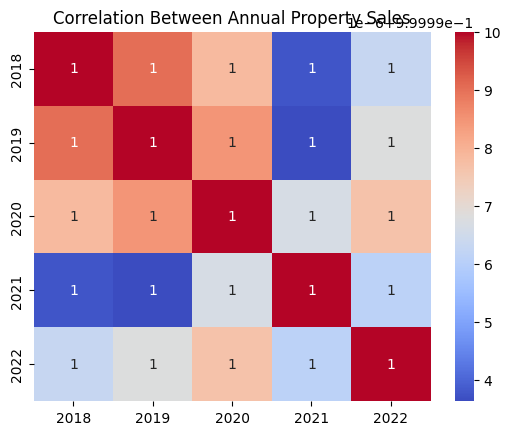

In [28]:
# Correlation between sales across years
correlation_matrix = Sales_England[['2018', '2019', '2020', '2021', '2022']].corr()

import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Between Annual Property Sales")
plt.show()

In [ ]:
#ADDITIONALLY WE WANT TO KNOW WHICH YEARS HAD THE MOST SALES AND???????

In [ ]:
# How many years does the anlysis include?
# Which years had the highest sales rate? And which district in England?
# Create new columns: Total sales per district and average per district
# Create new row: Total sales per year. Name area: Annual Sales in England or recallculate 'country: England'
# eliminate the word before the districts name e.g. ladu2023:Hartlepool
# Add histogram
# Add scatterplot
# WHO IS MAY AUDIENCE?
#
#
#
#

**MARKDOWN-NON-SPATIAL-VISUALISATION**

Who is my audience?
Data source and data explanation. Cite.

## References
<p><a href="add_url_here">[1]</a>Footnote citation goes here</p>
<p><a href="https://github.com/FrancescaPontin/GEOG5990">[2]</a>GEOG5990M course materials</p>
<p><a href="add_url_here">[3]</a>Citation 3</p>